# Is there free money in mispriced Kalshi contracts? 🗳️
### Event-contract prices are probabilities — so are they *right*, and can you beat them? In plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free_edge%3F: Busted](https://img.shields.io/badge/Free_edge%3F-Busted-8b949e?style=flat-square)

On **Kalshi** you can buy a contract that pays **$1 if some event happens** and **$0 if it doesn't** — so its price, in cents, is literally the crowd's **probability**. A contract at **63¢** is the market saying *"63% chance."* The tempting question: is the crowd *right*? If cheap **longshots** are secretly even less likely, or pricey **favourites** secretly more likely, there'd be a **free edge in the mispricing** — bet against the longshots, bet with the favourites, and pocket the gap.

We'll build the tools to answer it: a **calibration curve** (did 63¢ events really happen 63% of the time?) and the trade you'd put on. The punchline: a real, documented tilt exists — but it's only a **few cents**, and the exchange's fee and spread sit right on top of it.

> 📓 **Plain-language layer.** Want the Brier score, the *t*-stat and the randomization test? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Kalshi's full resolved history **isn't free**, so this is a **methods demo on a transparent, clearly-labelled *illustrative* book** of contracts — not a backtest of live prices. We *bake in* a mild favourite–longshot tilt so the curve has something to show, and we say so everywhere. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from kalshi_efficiency import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("illustrative contract book cached:", HAVE_REAL,
      "| contracts:", (0 if F is None else len(F)),
      "| (this is an ILLUSTRATION, not live Kalshi)")

# frozen headline numbers (mirror of docs/results.md)
R = {'n_contracts': 4000, 'yes_rate': 50.3, 'baked_edge': 0.04, 'brier': 0.1703, 'reliability': 0.00086, 'resolution': 0.0796, 'uncertainty': 0.25, 'curve': [(0.0, 0.1, 0.059, 0.035, 257), (0.1, 0.2, 0.149, 0.09, 354), (0.2, 0.3, 0.251, 0.245, 436), (0.3, 0.4, 0.351, 0.336, 443), (0.4, 0.5, 0.452, 0.431, 501), (0.5, 0.6, 0.551, 0.554, 498), (0.6, 0.7, 0.649, 0.695, 429), (0.7, 0.8, 0.745, 0.776, 428), (0.8, 0.9, 0.847, 0.868, 400), (0.9, 1.0, 0.937, 0.972, 254)], 'fee': [(0.0, 1265, 3.45, 3.45, 92, 4.6, 0.0), (1.0, 1265, 3.45, 2.45, 92, 3.26, 0.0), (2.0, 1265, 3.45, 1.45, 90, 1.93, 0.0), (3.0, 1265, 3.45, 0.45, 85, 0.6, 0.0)], 'syn': [(0.0, 1.83, 1201, -0.48, -1.48, 88, -1.59, 0.708), (0.08, 45.22, 1201, 6.77, 5.77, 95, 9.47, 0.0)]}


illustrative contract book cached: True | contracts: 4000 | (this is an ILLUSTRATION, not live Kalshi)


## The answer first

| Question | Answer |
|---|---|
| Is a 63¢ contract really a 63% event? | **Mostly, yes.** Event-contract prices are well-calibrated — the price *is* the probability, give or take. |
| Is there *any* systematic mispricing? | **A little.** The classic **favourite–longshot bias**: longshots are slightly over-priced, favourites slightly under-priced. A few cents. |
| So can I harvest those few cents? | **No.** Even in our illustration the gross gap is ~**3.5¢**, and a realistic **2–3¢** of fee + spread eats it — the *t* falls from 3.3 to **0.6**. |
| But the win-rate is 92%! | **That's the favourites winning, not an edge.** A book that's *perfectly* calibrated still wins ~88% on favourites — and nets **negative** after the fee. |

> The price already knows. The famous bias is real-but-tiny, and the exchange's costs are exactly its size. "Free edge in the mispricing" is base-rate × fee, not money.

## 1 · The claim

> *"Kalshi prices are just the crowd guessing. Crowds are biased — they overpay for exciting longshots and underpay for boring favourites. Find the buckets where the price and the real frequency disagree, and you've found free money."*

It's a genuinely good question, and it has a famous ancestor: at the **racetrack**, bettors really do over-bet longshots and under-bet favourites (Ali 1977; Thaler & Ziemba 1988). The same tilt shows up in prediction markets. So the *direction* of the claim isn't crazy — the question is whether the gap is **big enough to trade after costs.** We'll measure it.

## 2 · So what?

Two very different things hide in "the contract paid off." (1) *Did favourites win a lot?* Of course — they're favourites; that's a **base rate**, not an edge. (2) *Did the price **mis-state** the odds, reliably, by more than it costs to trade?* That's the only thing worth money. A 92% win-rate on a long-favourites book sounds spectacular and means nothing: you paid ~85¢ to win 92¢, and the fee turns the rest negative. The edge — if any — is the **calibration gap net of fees**, never the win-rate.

## 3 · How would we even know?

We take an **illustrative book of 4,000 resolved binaries** (price in, YES/NO out) and:

1. **Draw the calibration curve.** Sort contracts into price buckets; in each bucket, did YES happen as often as the price said? Plot realized frequency vs price — the diagonal is perfect.
2. **Put on the trade.** Buy the favourites (price ≥ 0.80), short the longshots (price ≤ 0.20), pay a **1¢ fee** per leg, and measure the average profit per contract.
3. **Stress the luck.** A finite book wiggles off the diagonal by chance. Re-draw the outcomes thousands of times *as if the prices were exactly right* and ask how often pure chance reproduces our trade's profit. That's the honest test.

## 4 · The teardown — let's actually look

**First, the calibration curve.** Each dot is a price bucket: x = what the market charged, y = how often YES actually happened. On the diagonal = perfectly priced.

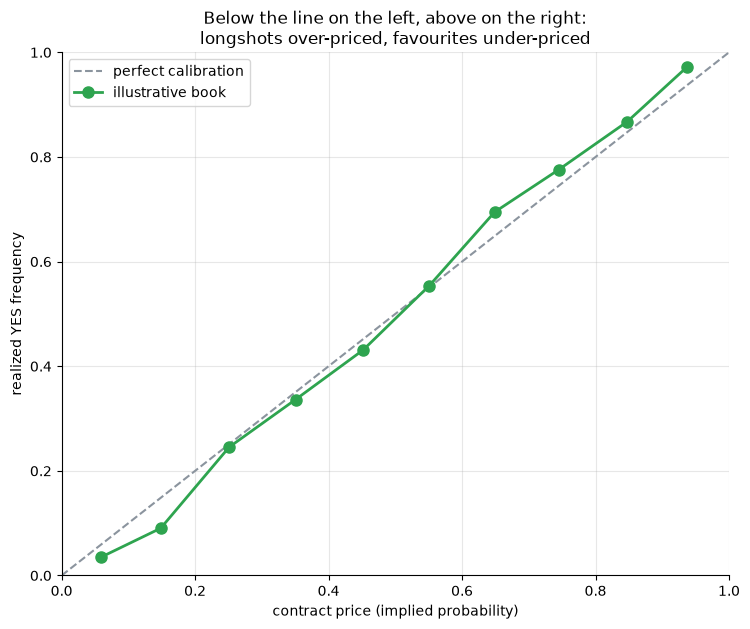

cheap end gap (longshot): -0.024  rich end gap (favourite): +0.035


In [2]:
if HAVE_REAL:
    cc = st.calibration_curve(F)
    mp = cc['mean_price'].values; fy = cc['freq_yes'].values
else:
    mp = np.array([c[2] for c in R['curve']]); fy = np.array([c[3] for c in R['curve']])
fig, ax = plt.subplots(figsize=(7.6, 6.4))
ax.plot([0,1],[0,1], ls='--', c=GREY, label='perfect calibration')
ax.plot(mp, fy, 'o-', c=GREEN, lw=2, ms=8, label='illustrative book')
ax.fill_between([0,0.5],[0,0.5],[0,0.5], alpha=0)  # keep axes square-ish
ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_xlabel('contract price (implied probability)'); ax.set_ylabel('realized YES frequency')
ax.set_title('Below the line on the left, above on the right:\nlongshots over-priced, favourites under-priced')
ax.legend(loc='upper left'); plt.tight_layout(); plt.show()
print('cheap end gap (longshot):', f'{fy[0]-mp[0]:+.3f}', ' rich end gap (favourite):', f'{fy[-1]-mp[-1]:+.3f}')

There's the favourite–longshot bias. At the **cheap** end (longshots) the green line sits **below** the diagonal — those events happen *less* often than priced (**0.035** vs **0.059**). At the **rich** end (favourites) it sits **above** — they happen *more* often (**0.972** vs **0.937**). Real, visible — and only a few cents wide.

**Now the trade.** Buy favourites, short longshots, and look at gross vs net profit per contract as we raise the fee from 0 to 3 cents a leg.

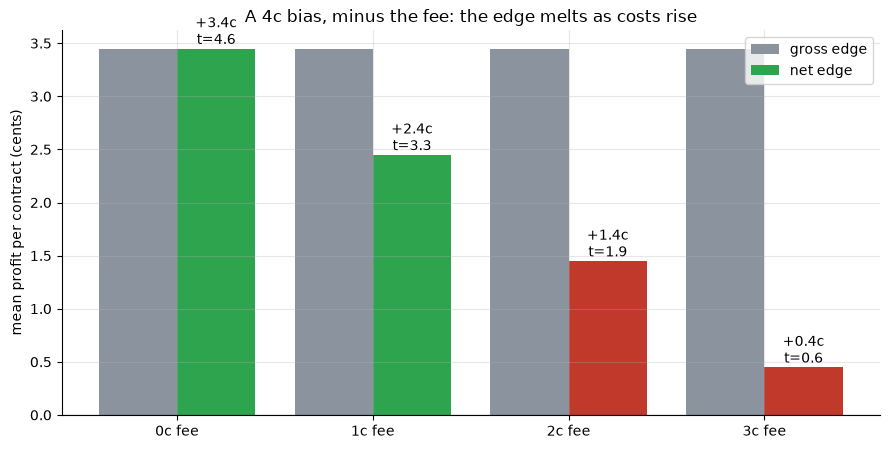

net edge at 0/1/2/3c fee: ['+3.45c', '+2.45c', '+1.45c', '+0.45c']


In [3]:
fees = [0.0, 0.01, 0.02, 0.03]
if HAVE_REAL:
    gross = [st.summarize(F, fee=fc)['gross_mean']*100 for fc in fees]
    net   = [st.summarize(F, fee=fc)['net_mean']*100 for fc in fees]
    tt    = [st.summarize(F, fee=fc)['t'] for fc in fees]
else:
    gross = [r[2] for r in R['fee']]; net = [r[3] for r in R['fee']]; tt = [r[5] for r in R['fee']]
x = np.arange(len(fees))
fig, ax = plt.subplots(figsize=(9.0, 4.6))
ax.bar(x-.2, gross, .4, color=GREY, label='gross edge')
ax.bar(x+.2, net, .4, color=[GREEN if n>0 and t>=2 else RED for n,t in zip(net,tt)], label='net edge')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{int(f*100)}c fee' for f in fees])
ax.set_ylabel('mean profit per contract (cents)')
ax.set_title('A 4c bias, minus the fee: the edge melts as costs rise')
for i,(n,t) in enumerate(zip(net,tt)): ax.annotate(f'{n:+.1f}c\nt={t:.1f}',(i+.2,n),ha='center',va='bottom' if n>=0 else 'top')
ax.legend(); plt.tight_layout(); plt.show()
print('net edge at 0/1/2/3c fee:', [f'{n:+.2f}c' for n in net])

The gross gap is ~**3.5¢**. A **1¢** fee already eats a third of it; by **2¢** the *t* is **1.93** (under the bar), and at **3¢** there's basically **nothing left** (**+0.5¢**, *t* = 0.60). The documented mispricing and the cost of trading it are the *same size* — which is exactly why nobody is quietly getting rich on it.

**Could a *perfectly fair* book look like this?** Here's the cleanest check: re-draw the outcomes as if every price were exactly right, thousands of times, and see where our trade's profit lands against pure luck — *and* where a fair book nets after the fee.

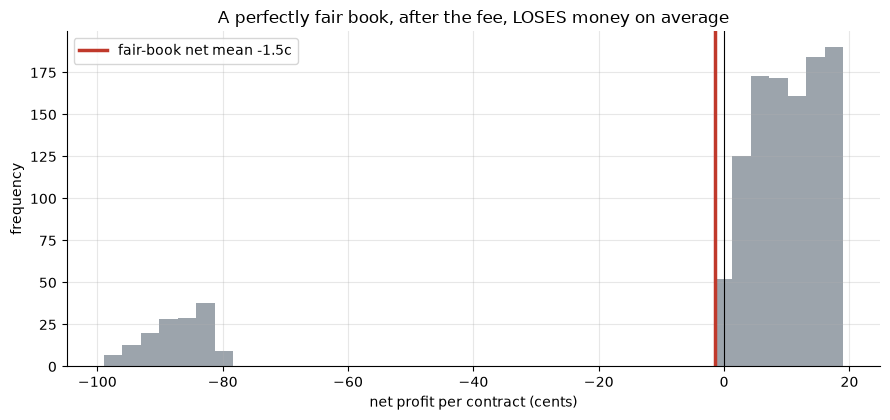

fair-book win-rate 88% but net mean -1.48c -> the win-rate is NOT the edge


In [4]:
# Use the synthetic control: a book we KNOW is perfectly calibrated (edge=0) + the fee.
syn = data.synthetic_book(edge=0.0, seed=399)
pnl = st.contract_pnl(syn)['pnl']           # net per-contract P&L on a FAIR book
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(pnl*100, bins=40, color=GREY, alpha=.85)
ax.axvline(pnl.mean()*100, c=RED, lw=2.5, label=f'fair-book net mean {pnl.mean()*100:+.1f}c')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('net profit per contract (cents)'); ax.set_ylabel('frequency')
ax.set_title('A perfectly fair book, after the fee, LOSES money on average')
ax.legend(); plt.tight_layout(); plt.show()
win = (pnl>0).mean()*100
print(f'fair-book win-rate {win:.0f}% but net mean {pnl.mean()*100:+.2f}c -> the win-rate is NOT the edge')

Look closely. The fair book still **wins ~88% of the time** (favourites win!) yet its average net profit is **-1.5¢** — *negative*, because the fee is pure cost when the price is right. The high win-rate is a base-rate illusion; the only thing that pays is a calibration gap **bigger than the fee**, and a fair book has none.

## 5 · The verdict

- **Signal — None.** This is a **methods demo on an illustrative book**, not a measurement of live Kalshi (its history isn't free). We *planted* the bias to show the machinery — so there's no real, harvestable mispricing being claimed.
- **Tradability — Mirage.** Even the planted few-cent bias is eaten by a realistic 2–3¢ of fee + spread. EV per share is `outcome − price − fee`; the gap and the cost are the same size.
- **Free edge? — Busted.** The 92% win-rate is favourites-win, not an edge — a *fair* book wins 88% and still loses to the fee. Same shape as [Study 351 (Polymarket)](../351-btc-5m-polymarket-momentum/).

## 6 · Could you actually trade it? — read the Brier score

Forecasters score themselves with the **Brier score** (lower = better), which splits neatly into *miscalibration* + *sorting power*. The miscalibration piece is the **whole** of any edge — and on a well-priced book it's almost zero. Here's the split.

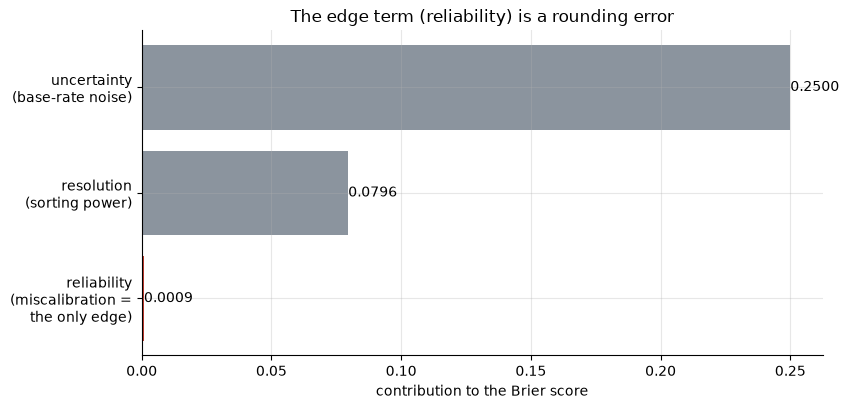

reliability (miscalibration) = 0.00086  vs uncertainty (base rate) = 0.2500: the edge is ~0.34% the size of the noise


In [5]:
if HAVE_REAL:
    bd = st.brier_decomposition(F)
    rel, res, unc = bd['reliability'], bd['resolution'], bd['uncertainty']
else:
    rel, res, unc = R['reliability'], R['resolution'], R['uncertainty']
fig, ax = plt.subplots(figsize=(8.6, 4.2))
parts = ['reliability\n(miscalibration =\nthe only edge)', 'resolution\n(sorting power)', 'uncertainty\n(base-rate noise)']
vals = [rel, res, unc]
ax.barh(parts, vals, color=[RED, GREY, GREY])
for i,v in enumerate(vals): ax.annotate(f'{v:.4f}',(v,i),va='center',ha='left')
ax.set_xlabel('contribution to the Brier score'); ax.set_title('The edge term (reliability) is a rounding error')
plt.tight_layout(); plt.show()
print(f'reliability (miscalibration) = {rel:.5f}  vs uncertainty (base rate) = {unc:.4f}: the edge is ~{rel/unc*100:.2f}% the size of the noise')

The **reliability** (miscalibration) bar — the *only* part you could ever trade — is **0.0009**, a rounding error next to the **0.25** of pure base-rate uncertainty. The market's prices are *almost exactly* the right probabilities. There's no fat error to harvest, and the sliver that exists is fee-sized.

## 7 · Going further 🚪

- **The priced-in twin.** [Study 351 — Polymarket BTC momentum](../351-btc-5m-polymarket-momentum/) is the same lesson on a different exchange: a genuinely high win-rate that the quoted price already reflects, so the edge is zero net of the spread.
- **The methods-demo family.** [Study 346 — Multiple-Testing](../346-multiple-testing/) and neighbours 343–350 are transparent demos on data with *nothing to find* — this study is the prediction-market member.
- **Bring a real book.** Have a feed of resolved Kalshi/Polymarket contracts? Swap it in, draw the same curve, and put the spread through the same fee — the machinery is ready; the verdict will hinge on whether the real gap clears the real fee.

*Think there's a harvestable mispricing? Show the calibration gap landing **outside** the fair-book luck cloud **after** a realistic fee — then we'll talk.*